In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\Admin\Documents\PROJECTS\Industrial Machine Failure Prediction\raw data.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [4]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


In [6]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

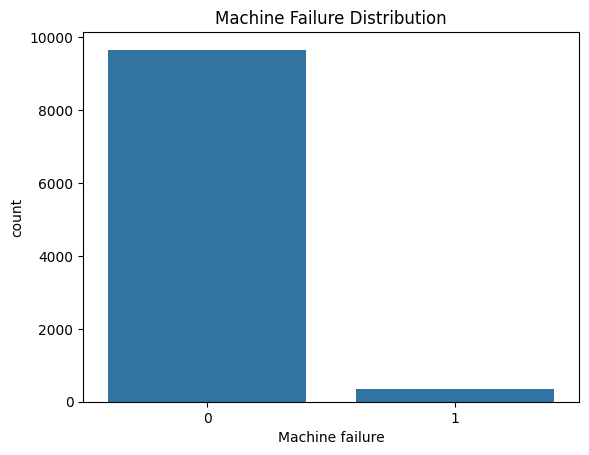

In [9]:
sns.countplot(x='Machine failure', data = df)
plt.title('Machine Failure Distribution')
plt.show()

In [10]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [11]:
df['Type'].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [12]:
df['Product ID'].nunique()

10000

In [13]:
df.groupby('Type')['Machine failure'].agg(['count','sum','mean'])

,count,sum,mean
Type,,,
H,1003,21,0.020937
L,6000,235,0.039167
M,2997,83,0.027694


In [14]:
df.groupby("Machine failure")[["TWF", "HDF", "PWF", "OSF", "RNF"]].sum()

,TWF,HDF,PWF,OSF,RNF
Machine failure,,,,,
0,0,0,0,0,18
1,46,115,95,98,1


In [15]:
sensor_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"]
df.groupby("Machine failure")[sensor_cols].mean().T

Machine failure,0,1
Air temperature [K],299.973999,300.886431
Process temperature [K],309.995570,310.290265
Rotational speed [rpm],1540.260014,1496.486726
Torque [Nm],39.629655,50.168142
Tool wear [min],106.693717,143.781711


In [16]:
means = df.groupby("Machine failure")[sensor_cols].mean().T
means["difference"] = means[1] - means[0]

means

Machine failure,0,1,difference
Air temperature [K],299.973999,300.886431,0.912432
Process temperature [K],309.995570,310.290265,0.294696
Rotational speed [rpm],1540.260014,1496.486726,-43.773289
Torque [Nm],39.629655,50.168142,10.538486
Tool wear [min],106.693717,143.781711,37.087994


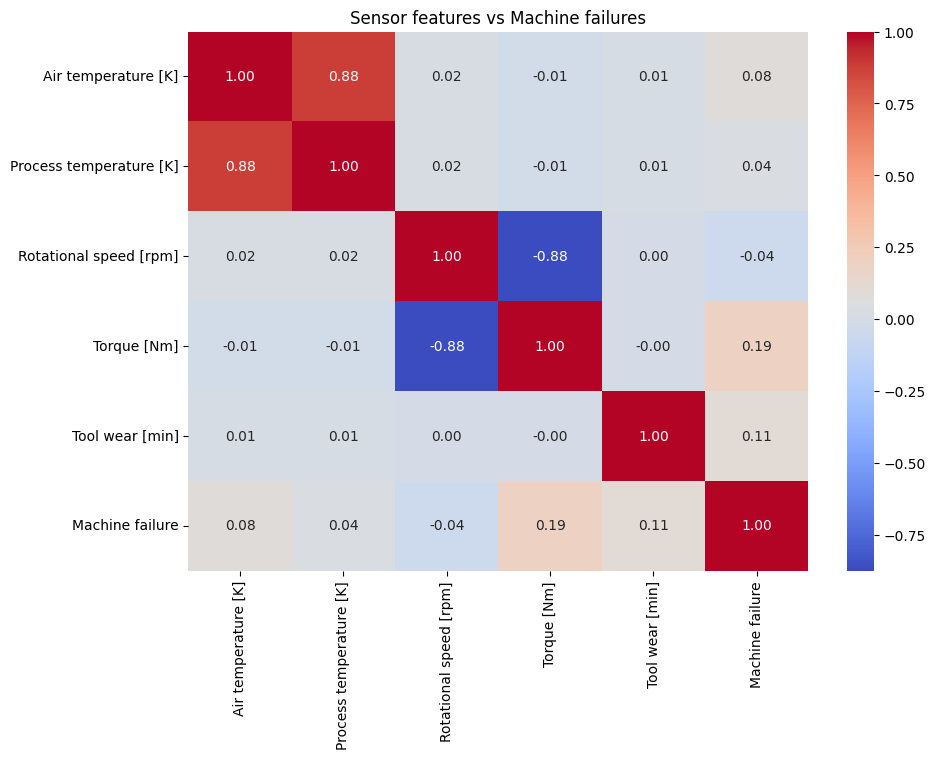

In [17]:
plt.figure(figsize=(10,7))
sns.heatmap(df[sensor_cols + ["Machine failure"]].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Sensor features vs Machine failures')
plt.show()

In [18]:
df["Temperature difference"] = (df["Process temperature [K]"] - df["Air temperature [K]"])
df["Mechanical power"] = (df["Torque [Nm]"] * df["Rotational speed [rpm]"])

In [19]:
df[["Temperature difference",
    "Mechanical power",
    "Machine failure"]].describe()

,Temperature difference,Mechanical power,Machine failure
count,10000.000000,10000.000000,10000.000000
mean,10.000630,59967.147040,0.033900
std,1.001094,10193.093881,0.180981
min,7.600000,10966.800000,0.000000
25%,9.300000,53105.400000,0.000000
50%,9.800000,59883.900000,0.000000
75%,11.000000,66873.750000,0.000000
max,12.100000,99980.400000,1.000000


In [20]:
df.groupby('Machine failure')[["Temperature difference","Mechanical power"]].mean()

,Temperature difference,Mechanical power
Machine failure,,
0,10.021571,59631.036446
1,9.403835,69545.803245


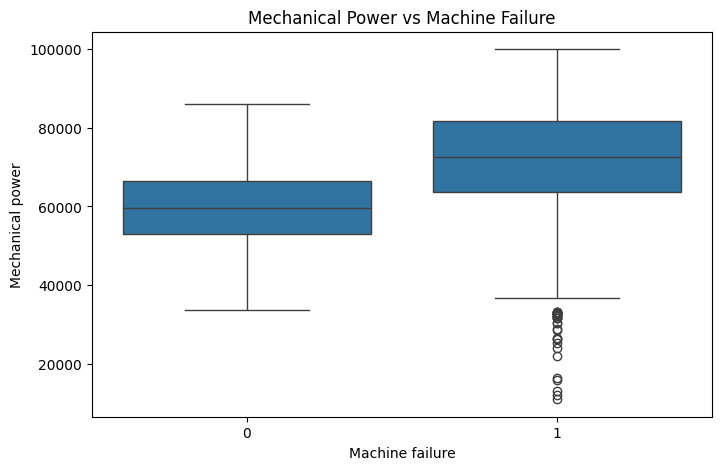

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Machine failure",
    y="Mechanical power",
    data=df)

plt.title("Mechanical Power vs Machine Failure")
plt.show()

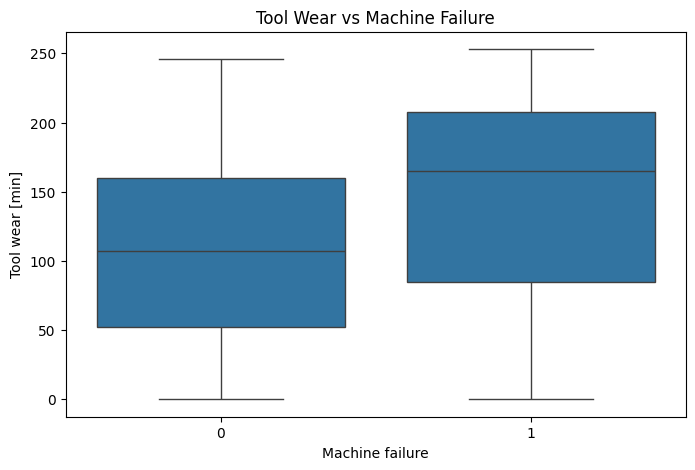

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Machine failure",
    y="Tool wear [min]",
    data=df)

plt.title("Tool Wear vs Machine Failure")
plt.show()

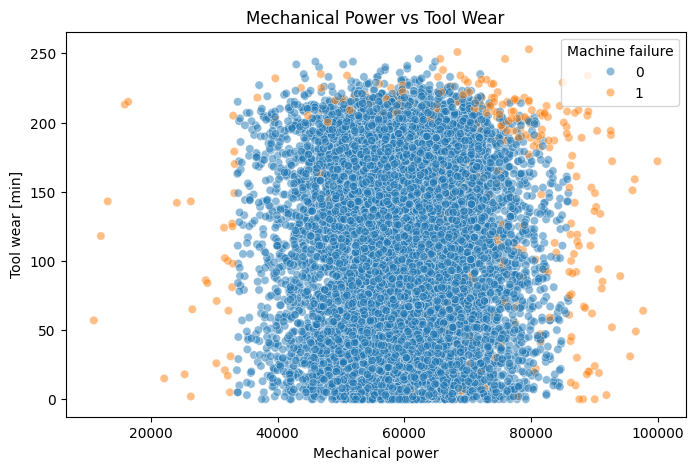

In [23]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Mechanical power",
    y="Tool wear [min]",
    hue="Machine failure",
    alpha=0.5
)

plt.title("Mechanical Power vs Tool Wear")
plt.show()

In [24]:
features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature difference",
    "Mechanical power"
]


In [25]:
x = df[features]
y = df['Machine failure']
x.shape

(10000, 8)

In [26]:
x.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature difference,Mechanical power
0,M,298.1,308.6,1551,42.8,0,10.5,66382.8
1,L,298.2,308.7,1408,46.3,3,10.5,65190.4
2,L,298.1,308.5,1498,49.4,5,10.4,74001.2
3,L,298.2,308.6,1433,39.5,7,10.4,56603.5
4,L,298.2,308.7,1408,40.0,9,10.5,56320.0


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42, stratify=y)

In [28]:
print("Train failure rate:", y_train.mean())
print("Test failure rate:", y_test.mean())

Train failure rate: 0.033875
Test failure rate: 0.034


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

categorical_features = ["Type"]

numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature difference",
    "Mechanical power"
]

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown="ignore"), categorical_features)]
)

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV


In [32]:



models = {

    "Logistic Regression": (
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ),
        {
            "model__C": [0.01, 0.1, 1, 10],
            "model__solver": ["liblinear", "lbfgs"]
        }
    ),

    "Decision Tree": (
        DecisionTreeClassifier(
            class_weight="balanced",
            random_state=42
        ),
        {
            "model__max_depth": [3, 5, 10, 15, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 5, 10],
            "model__criterion": ["gini", "entropy"]
        }
    ),

    "Random Forest": (
        RandomForestClassifier(
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),
        {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, 15, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 5],
            "model__max_features": ["sqrt", "log2"]
        }
    ),

    "Gradient Boosting": (
        GradientBoostingClassifier(
            random_state=42
        ),
        {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [2, 3, 5],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 5]
        }
    ),

    "XGBoost": (
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ),
        {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [3, 5, 7],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    ),

    "CatBoost": (
        CatBoostClassifier(
            verbose=False,
            random_state=42
        ),
        {
            "model__iterations": [100, 200, 300],
            "model__depth": [4, 6, 8],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__l2_leaf_reg": [1, 3, 5]
        }
    )
}

In [33]:
results={}

for name, (model,param_grid) in models.items():

    prediction_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    grid = GridSearchCV(
        estimator=prediction_model,
        param_grid=param_grid,
        cv=5,
        scoring="average_precision",
        n_jobs=-1,
        verbose=1
    )
    
    grid.fit(X_train, y_train)
    results[name]=grid
    print(f"\n{name}")
    print("Best Parameters:", grid.best_params_)
    print("Best CV PR-AUC:", grid.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Logistic Regression
Best Parameters: {'model__C': 0.1, 'model__solver': 'liblinear'}
Best CV PR-AUC: 0.4880820011743114
Fitting 5 folds for each of 120 candidates, totalling 600 fits

Decision Tree
Best Parameters: {'model__criterion': 'gini', 'model__max_depth': 5, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
Best CV PR-AUC: 0.8064512162058456
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Random Forest
Best Parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best CV PR-AUC: 0.867182297736796
Fitting 5 folds for each of 162 candidates, totalling 810 fits

Gradient Boosting
Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV PR-AUC: 0.8915434576327925
Fitting 5 folds for e

In [34]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    average_precision_score,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score
)

In [35]:
for name, grid in results.items():

    y_pred = grid.predict(X_test)
    y_prob = grid.predict_proba(X_test)[:, 1]

    print("Model:",name)
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, y_pred))

    print("ROC-AUC:",
      roc_auc_score(y_test, y_prob))

    print("PR-AUC:",
        average_precision_score(y_test, y_prob))
    print('\n\n')

Model: Logistic Regression
Confusion Matrix:
[[1644  288]
 [   9   59]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.85      0.92      1932
           1       0.17      0.87      0.28        68

    accuracy                           0.85      2000
   macro avg       0.58      0.86      0.60      2000
weighted avg       0.97      0.85      0.90      2000

Balanced Accuracy: 0.8592893679210816
ROC-AUC: 0.9285714285714286
PR-AUC: 0.45042343506167754



Model: Decision Tree
Confusion Matrix:
[[1825  107]
 [   7   61]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1932
           1       0.36      0.90      0.52        68

    accuracy                           0.94      2000
   macro avg       0.68      0.92      0.74      2000
weighted avg       0.97      0.94      0.95      2000

Balanced Accuracy: 0.9208379003775423
ROC-AUC: 0.92971699549384

In [36]:

final_model = results["Gradient Boosting"].best_estimator_

y_prob = final_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.05)

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.10 | Precision: 0.621 | Recall: 0.868 | F1: 0.724
Threshold: 0.15 | Precision: 0.725 | Recall: 0.853 | F1: 0.784
Threshold: 0.20 | Precision: 0.773 | Recall: 0.853 | F1: 0.811
Threshold: 0.25 | Precision: 0.853 | Recall: 0.853 | F1: 0.853
Threshold: 0.30 | Precision: 0.875 | Recall: 0.824 | F1: 0.848
Threshold: 0.35 | Precision: 0.902 | Recall: 0.809 | F1: 0.853
Threshold: 0.40 | Precision: 0.931 | Recall: 0.794 | F1: 0.857
Threshold: 0.45 | Precision: 0.931 | Recall: 0.794 | F1: 0.857
Threshold: 0.50 | Precision: 0.964 | Recall: 0.794 | F1: 0.871
Threshold: 0.55 | Precision: 0.964 | Recall: 0.779 | F1: 0.862
Threshold: 0.60 | Precision: 0.963 | Recall: 0.765 | F1: 0.852
Threshold: 0.65 | Precision: 0.981 | Recall: 0.765 | F1: 0.860
Threshold: 0.70 | Precision: 0.981 | Recall: 0.750 | F1: 0.850
Threshold: 0.75 | Precision: 0.979 | Recall: 0.691 | F1: 0.810
Threshold: 0.80 | Precision: 1.000 | Recall: 0.662 | F1: 0.796
Threshold: 0.85 | Precision: 1.000 | Recall: 0.647 | F1

In [37]:
threshold = 0.25

y_prob = final_model.predict_proba(X_test)[:, 1]

y_pred = (y_prob >= threshold).astype(int)

In [38]:
print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, y_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob))

print("PR-AUC:",
      average_precision_score(y_test, y_prob))

[[1922   10]
 [  10   58]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.85      0.85      0.85        68

    accuracy                           0.99      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.99      0.99      0.99      2000

Balanced Accuracy: 0.9238825965168675
ROC-AUC: 0.9735834551211789
PR-AUC: 0.8984537947310641


In [39]:
import shap

preprocessor = final_model.named_steps["preprocessor"]
model = final_model.named_steps["model"]

X_test_transformed = preprocessor.transform(X_test)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values shape:", shap_values.shape)
print("Data shape:", X_test_transformed.shape)

SHAP values shape: (2000, 10)
Data shape: (2000, 10)


In [71]:
features = preprocessor.get_feature_names_out()
feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in features
]

print(feature_names)

['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temperature difference', 'Mechanical power', 'Type_H', 'Type_L', 'Type_M']


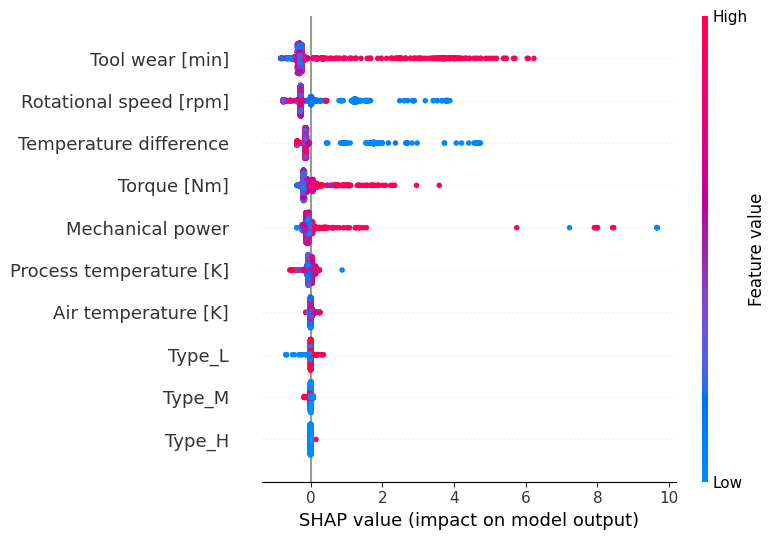

In [72]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)


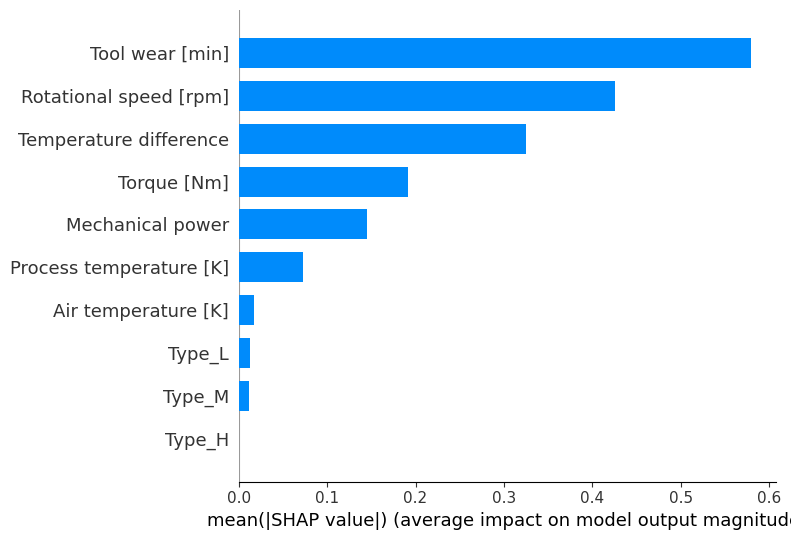

In [73]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

In [74]:
shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP|": np.abs(shap_values).mean(axis=0)
}).sort_values("Mean |SHAP|", ascending=False)

print(shap_importance)

                   Feature  Mean |SHAP|
4          Tool wear [min]     0.579187
2   Rotational speed [rpm]     0.425956
5   Temperature difference     0.324644
3              Torque [Nm]     0.191063
6         Mechanical power     0.144943
1  Process temperature [K]     0.072337
0      Air temperature [K]     0.017129
8                   Type_L     0.012576
9                   Type_M     0.011487
7                   Type_H     0.000234


In [75]:
sample_index_0 = 0

print("Actual:", y_test.iloc[sample_index_0])

probability_0 = final_model.predict_proba(
    X_test.iloc[[sample_index_0]]
)[0, 1]

prediction_0 = int(probability >= 0.25)

print("Failure probability:", probability_0)
print("Prediction:", prediction_0)

Actual: 0
Failure probability: 0.019523868519273607
Prediction: 1


In [76]:
X_sample = X_test.iloc[[sample_index_0]]

X_sample_transformed = final_model.named_steps["preprocessor"].transform(X_sample)

sample_shap = explainer(X_sample_transformed)

print("SHAP values:")
print(sample_shap.values)

SHAP values:
[[ 2.85117248e-02  2.21624840e-02  1.21483561e+00  1.38815230e+00
  -8.24582694e-01 -3.77024902e-01  3.94866662e-01 -2.84740031e-05
   2.52957926e-02  3.87661194e-03]]


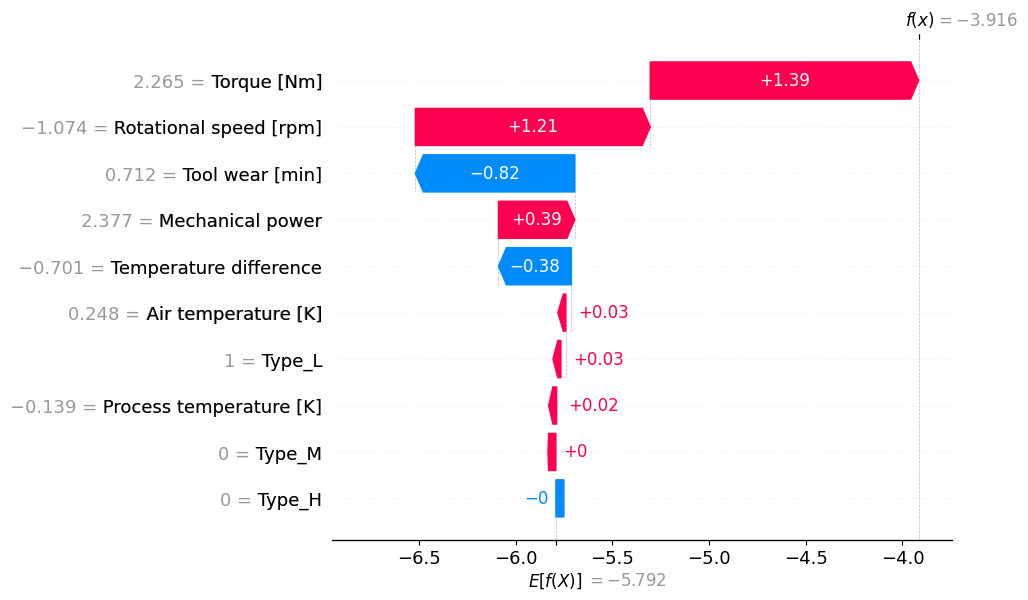

In [78]:
sample_shap.feature_names = feature_names


shap.plots.waterfall(sample_shap[0])


In [79]:
failure_indices = np.where(y_test.values == 1)[0]

print(failure_indices[:10])

[ 17  21  40  43  64  65  97 121 127 144]


In [80]:
sample_index_1 = failure_indices[0]

X_sample = X_test.iloc[[sample_index_1]]

probability_1 = final_model.predict_proba(X_sample)[0, 1]
prediction_1 = int(probability >= 0.25)

print("Actual:", y_test.iloc[sample_index_1])
print("Failure probability:", probability_1)
print("Prediction:", prediction_1)

Actual: 1
Failure probability: 0.880661430261304
Prediction: 1


In [81]:
X_sample = X_test.iloc[[sample_index_1]]

X_sample_transformed = final_model.named_steps["preprocessor"].transform(X_sample)

sample_shap_1 = explainer(X_sample_transformed)

print("SHAP values:")
print(sample_shap_1.values)

SHAP values:
[[ 3.60958658e-02 -2.30636852e-01  3.65896685e+00  8.54037349e-02
  -1.51129691e-01  4.40876489e+00 -2.30912029e-02 -2.84740031e-05
   2.95261014e-03  3.87661194e-03]]


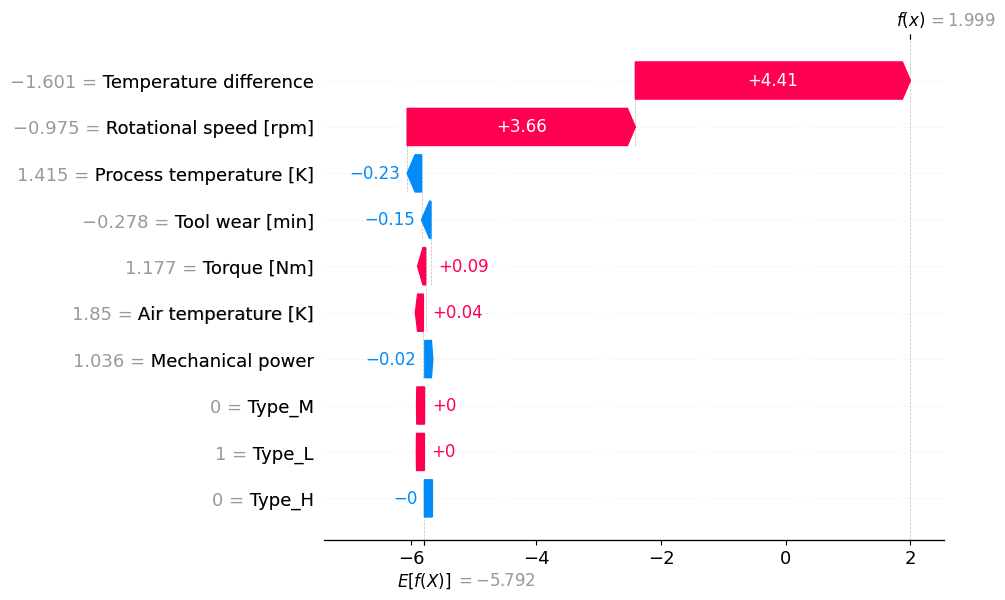

In [82]:
sample_shap_1.feature_names = feature_names


shap.plots.waterfall(sample_shap_1[0])